# Introduction

In [1]:
import numpy as np
import csv
import pandas as pd
import math
import matplotlib.pyplot as plt
from tqdm import tqdm

# Problem I

In [2]:
# import csv files
# Import the training data
flight_data_train = np.loadtxt('flight_data_train.csv', delimiter = ',')
# Import the testing data
flight_data_test = np.loadtxt('flight_data_test.csv', delimiter = ',')

In [11]:
# Create function(s) to make Phi matrix
def make_Phi(data,m):
    Phi = []
    for row in data:
        # construct row features
        Phi.append(make_Phi_row(row[:-1],m)) 
    return Phi

def make_Phi_row(x,m):
    Phi_row = []
    for j in x:
        for i in range(m):
            Phi_row.append(j**(i + 1)) 
    Phi_row.append(1)
    return Phi_row


## Problem I.1
Linear Regression

100%|██████████| 16/16 [00:01<00:00, 15.98it/s]


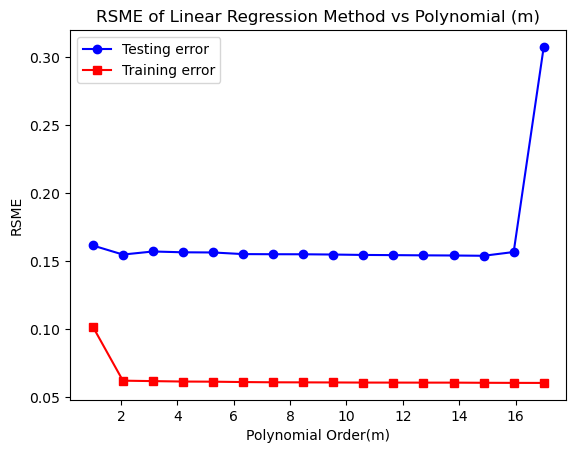

In [4]:
# Normalize data
minTrain = np.min(flight_data_train,axis = 0)
maxTrain = np.max(flight_data_train,axis = 0)
train_normalize =   (flight_data_train - minTrain)/(maxTrain - minTrain)

minTest = np.min(flight_data_test,axis = 0)
maxTest = np.max(flight_data_test,axis = 0)
test_normalize = (flight_data_test - minTest)/(maxTest - minTest)

trainingError = []
testingError = []

poly_range = 16
for m in tqdm(range(poly_range)):
    
    # Build matrix Phi
    Phi_train = make_Phi(train_normalize,m)
    # Test accuracy against 2nd data set
    Phi_test = make_Phi(test_normalize,m)
    m += 1
    
    # Remove the inputs from the data
    tTrain = train_normalize[:,-1]
    tTest  = test_normalize[:,-1]
    ## Compute Moore-Penrose Psuedoinverse (MPP) of Phi matrix
    # Perform Singular Value Decomposition
    # U_phi, s_phi, V_phi = np.linalg.svd(Phi_train)
    # Sigma_phi = np.diag(s_phi)
    # Phi_train_MPP = np.dot(U_phi.T , np.dot( np.linalg.inv(Sigma_phi) , V_phi.T))
    
    # Calculate weights with two different methods (SVD MPP and built in MPP)
    weights = np.matmul(np.linalg.pinv(Phi_train),tTrain);
    
    # Check the outputs
    yTrain = np.matmul(Phi_train,weights)
    yTest = np.matmul(Phi_test,weights) 

    # Calculate training and test error
    trainingError.append(np.sqrt(np.square(yTrain-tTrain).mean() ) ) 
    testingError.append(np.sqrt( np.square(yTest -tTest ).mean() ) )
    
# Plot results
plt.figure()
plt.plot(np.linspace(1,m+1,m),testingError,  'bo-', label = 'Testing error')
plt.plot(np.linspace(1,m+1,m),trainingError, 'rs-',label = 'Training error')
# plt.ylim([0,0.16])
plt.xlabel("Polynomial Order(m)")
plt.ylabel("RSME")
plt.legend()
plt.title('RSME of Linear Regression Method vs Polynomial (m)')
plt.show()

## Problem 1.2
Ridge Regression

### Generate Data

In [74]:
from numpy.linalg import inv

# Normalize data
minTrain = np.min(flight_data_train,axis = 0)
maxTrain = np.max(flight_data_train,axis = 0)
train_normalize = (flight_data_train - minTrain) / (maxTrain - minTrain)

minTest        = np.min(flight_data_test,axis = 0)
maxTest        = np.max(flight_data_test,axis = 0)
test_normalize = (flight_data_test - minTest) / (maxTest - minTest)

trainingErrorRidge = []
testingErrorRidge = []

# Build lambda values:
num_vals = (len(train_normalize[0]) - 1) ** 2  + 1

ln_lambda_min = -30
ln_lambda_max =  20

ln_lambda_vals = np.linspace(ln_lambda_min,ln_lambda_max,num_vals)
lambda_vals = np.exp(ln_lambda_vals)


for lambda_val in tqdm(lambda_vals):
    
    # Build matrix Phi
    Phi_train = make_Phi(train_normalize,m)
    # Test accuracy 
    Phi_test = make_Phi(test_normalize,m)
    
    # Remove the inputs from the data
    tTrain = train_normalize[:,-1]
    tTest  = test_normalize[:,-1]
    
    # Calculate weights
    lambda_identity = lambda_val * np.identity(np.size(Phi_train[0]))
    weights = lambda_identity + np.matmul(np.transpose(Phi_train),Phi_train)
    weights = np.linalg.pinv(weights)
    weights = np.matmul(np.matmul(weights,np.transpose(Phi_train)),tTrain);

    
    # firstterm = np.linalg.pinv(np.exp(i)*I+Phi_prod)        # lambda = exp(i)
    # temp = np.matmul(firstterm,np.matmul(np.transpose(Phi_r),training_output))
    # weights_2.append(temp)
    
    # Check the outputs
    yTrain = np.matmul(Phi_train,weights)
    yTest =  np.matmul(Phi_test, weights) 

    # Calculate training and test error
    trainingErrorRidge.append( np.sqrt(np.square(yTrain-tTrain).mean() ) )
    testingErrorRidge.append(  np.sqrt(np.square(yTest -tTest).mean() ) )

100%|██████████| 37/37 [00:08<00:00,  4.18it/s]


### Plot Results

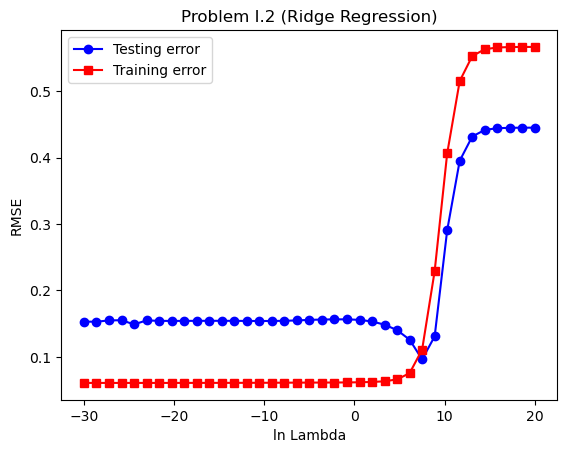

In [75]:
# Plot results
plt.plot(ln_lambda_vals,testingErrorRidge, 'bo-',label = 'Testing error')
plt.plot(ln_lambda_vals,trainingErrorRidge, 'rs-',label = 'Training error')
plt.xlabel("ln Lambda")
plt.ylabel("RMSE")
plt.title("Problem I.2 (Ridge Regression)")
plt.legend()
plt.show()

## Problem I.3
Lasso Regression

In [57]:
'''from numpy.linalg import inv
# Normalize data
minTrain = np.min(flight_data_train,axis = 0)
maxTrain = np.max(flight_data_train,axis = 0)
train_normalize = (flight_data_train - minTrain)/(maxTrain - minTrain)

minTest        = np.min(flight_data_test,axis = 0)
maxTest        = np.max(flight_data_test,axis = 0)
test_normalize = (flight_data_test - minTest)/(maxTest - minTest)

trainingErrorLasso = []
testingErrorLasso = []

# Build lambda values:
num_vals = (len(train_normalize[0]) - 1) ** 2  + 1

ln_lambda_min = -30
ln_lambda_max =  20

ln_lambda_vals = np.linspace(ln_lambda_min,ln_lambda_max,num_vals)
lambda_vals = np.exp(ln_lambda_vals)


for lambda_val in tqdm(lambda_vals):
    
    # Build matrix Phi
    Phi_train = make_Phi(train_normalize,m)
    # Test accuracy 
    Phi_test = make_Phi(test_normalize,m)
    
    # Remove the inputs from the data
    tTrain = train_normalize[:,-1]
    tTest  = test_normalize[:,-1]
    
    # Calculate weights
    lambda_identity = lambda_val * np.identity(np.size(Phi_train[0]))
    weights = lambda_identity + np.matmul(np.transpose(Phi_train),Phi_train)
    weights = inv(weights)
    weights = np.matmul(np.matmul(weights,np.transpose(Phi_train)),tTrain);

    
    # Check the outputs
    yTrain = np.matmul(Phi_train,weights)
    yTest =  np.matmul(Phi_test, weights) 

    # Calculate training and test error
    trainingErrorLasso.append( np.sqrt(np.square(yTrain-tTrain).mean() ) )
    testingErrorLasso.append(  np.sqrt(np.square(yTest -tTest).mean() ) )
    '''
print('fixme')

fixme


### Plot results

In [58]:
'''# Plot results
plt.plot(ln_lambda_vals,testingErrorLasso, 'bo-',label = 'Testing error')
plt.plot(ln_lambda_vals,trainingErrorLasso, 'rs-',label = 'Training error')
plt.xlabel("ln Lambda")
plt.ylabel("RMSE")
plt.title("Lasso Regression")
plt.legend()
plt.show()
'''
print('update with previous cell')

update with previous cell


# Problem II

# Problem 4

## Part II

In [9]:
# import csv files
# Import the training data
steel_data_train = np.loadtxt('steel_composition_train.csv', delimiter = ',')

In [53]:

def  colonelPartA (x,train):
    kern = []
    for row in train:
        kern.append((np.dot(x,row)+1) ** 2)
    return kern

def  kernalPartB (x,train):
    kern = []
    for row in train:
        kern.append((np.dot(x,row)+1) ** 3)
    return kern

def  kernalPartIII (x,train):
    kern = []
    for row in train:
        kern.append((np.dot(x,row)+1) ** 4)
    return kern

def  kernelPartD (x,train):
    kern = []
    Sigma  = 1
    for row in train:
        kern.append(np.exp(-np.linalg.norm(x-row)**2)/2*Sigma**2)
    return kern

minTrain = np.min(steel_data_train,axis = 0)
maxTrain = np.max(steel_data_train,axis = 0)
train_normalize = (steel_data_train - minTrain)/(maxTrain - minTrain)

# Constants
Lambda = 1

tTrain = train_normalize[:,:-1] # Data inputs
yTrain = train_normalize[:, -1] # Data outputs

trainingErrorA = []
trainingErrorB = []
trainingErrorD = []
trainingErrorC = []

# Make Phi matrices
Phi_2 =  make_Phi(train_normalize, 2)
Phi_3 = make_Phi(train_normalize, 3)

# Initialize K 
K2_gram = np.matmul(Phi_2,np.transpose(Phi_2))
# K3_gram = makePhi(train_normalize, 3)
# K4_gram = 
# Kgauss = 

for row in tqdm(tTrain):
    yA = np.transpose(yTrain) * (Lambda * np.eye(len(train_normalize)) * colonelPartA(row,tTrain))
    yB = np.transpose(yTrain) * (Lambda * np.eye(len(train_normalize)) * kernalPartB(row,tTrain))
    yC = np.transpose(yTrain) * (Lambda * np.eye(len(train_normalize)) * kernalPartIII(row,tTrain))
    yD = np.transpose(yTrain) * (Lambda * np.eye(len(train_normalize)) * kernelPartD(row,tTrain))
    trainingErrorA.append((yA-yTrain)**2)
    trainingErrorB.append((yB-yTrain)**2)
    trainingErrorD.append((yD-yTrain)**2)
    trainingErrorC.append((yC-yTrain)**2)

100%|██████████| 618/618 [00:23<00:00, 26.68it/s]


In [54]:
trainingErrorA=( np.sqrt(np.array(trainingErrorA).mean() ) )
trainingErrorB=( np.sqrt(np.array(trainingErrorB).mean() ) )
trainingErrorD=( np.sqrt(np.array(trainingErrorD).mean() ) )
trainingErrorC=( np.sqrt(np.array(trainingErrorC).mean() ) )
print(trainingErrorA)
print(trainingErrorB)
print(trainingErrorD)
print(trainingErrorC)

0.47219427312795076
0.4886770703839064
0.46899814762603453
0.566155094036725
